<a href="https://colab.research.google.com/github/sriharisrivathsanml-afk/SPAM-CLASSIFIICATION/blob/main/GOOGLE_DATA_ANALYTICS_CAPSTONE_ITER_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DESCRIPTION OF THE PROJECT**

## **WORKPLACE SCENARIO**
Salifort motors is a fictional , French - based clean energy company that designs , validates and builds vehicles running on green fuels such as electricity , solar energy , algae and hydrogen . The compnay boasts 10000 employees and is a global leader in this field .

## **THE ROLE AND THE TASK**
I play the role of a data specialist in Salifort motors . The Senior Leadership has tasked me with analyzing a past Employee Survey Data and come up with ideas of how to increase employee retention . For this , I have to design an accurate machine learning model that predicts whether or not an employee would leave the company , based on a number of features .

## **ABOUT THE DATASET**
The dataset consists of 14,999 rows and 10 columns . The descriptions of the columns are given below :-     
                                                               
    1. satisfaction_level -> A floating point number between 0 and 1 that depicts the employee's self reported satisfaction level
    2. last_evaluation -> A floating point number between 0 and 1 that depicts the employee's score in his last performance review
    3. number_project -> Number of projects the employee contributes to the company
    4. average_monthly_hours -> average number of hours the employee worked per month
    5. time_spend_company -> time in years that depicts how long the employee has been with the company
    6. work_accident -> signifies whether the employee suffered an accident at work
                        0 -> no accident
                        1 -> accident
    7. left (target) -> signifies whether or not the employee has left the company
                        0 -> has not left
                        1 -> has left
    8. promotion_last_5_years -> depicts whether or not the employee was promoted in the past 5 years
                                 0 -> Hasn't received promotion
                                 1 -> Received promotion
    9. department -> The employee's department
    10. salary -> The employee's salary

# **IMPORTING MODULES**
This section imports the python modules that will be used throughout the project

In [ ]:
#Importing modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.metrics import precision_score , recall_score , f1_score , accuracy_score
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

# **EXPLORATORY DATA ANALYSIS**
This section analyzes the dataset in detail and tries finding patterns & trends hidden in the dataset .

## **HIGH LEVEL ANALYSIS OF DATASET**

In [ ]:
#Loading the dataset
raw_data = pd.read_csv('/content/drive/MyDrive/GOOGLE DATA ANALYTICS CAPSTONE PROJECT /ES_Dataset.csv')

In [ ]:
#Getting information on the column data types and number of null values in each column of the dataset
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


**OBSERVATION** :- NO NULL VALUES !

In [ ]:
#Getting the descriptive statistics of the dataset
raw_data.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [ ]:
#Displaying the first 10 rows of the dataset to get comfortable with it
raw_data.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## **EXPLORING THE COLUMNS**

In [ ]:
#Fetching the departments and the number of employees working there
raw_data['Department'].value_counts()

,count
Department,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


**OBSERVATION**  : Most workers in sales department visa-vis management

In [ ]:
#Fetching the categories of salaries and the count of employees assosciated with them
raw_data['salary'].value_counts()

,count
salary,
low,7316
medium,6446
high,1237


**OBSERVATION** : While most employees under the low category , there are a significant bunch who get paid a medium salary .

### **DATA CLEANING**

#### **ENCODING TEXTUAL CATEGORIES**

In [ ]:
#Encoding textual categories using OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(raw_data[['salary', 'Department']])
feature_names = encoder.get_feature_names_out(['salary', 'Department'])
encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=raw_data.index)
raw_data = pd.concat([raw_data, encoded_df], axis=1)



#### **CHECKING FOR DUPLICATES**

In [ ]:
#Defining a function to chck duplicates
def check_duplicates(raw_data) :
  drop_duplicates_shape = raw_data.drop_duplicates().shape
  raw_data_shape = raw_data.shape
  if drop_duplicates_shape == raw_data_shape :
    print("No duplicates present !")
    print("Raw Data Shape : " , raw_data_shape)
  else :
    print("Duplicates present !")
    print("Raw Data Shape : " , raw_data_shape)
    print("No duplicates Data Shape : " , drop_duplicates_shape)


In [ ]:
#Calling the function
check_duplicates(raw_data)

Duplicates present !
Raw Data Shape :  (14999, 23)
No duplicates Data Shape :  (11991, 23)


In [ ]:
#Dropping the duplicates
data = raw_data.drop_duplicates()

#### **CHECKING FOR OUTLIERS IN NUMERICAL COLUMNS**

In [ ]:
#Defining the outlier detection and removal function
def outliers(X) :
  limits = []
  lower_limit = X.quantile(0.25) - 1.5 * (X.quantile(0.75) - X.quantile(0.25))
  upper_limit = X.quantile(0.75) + 1.5 * (X.quantile(0.75) - X.quantile(0.25))
  for value in X.values :
    if value < lower_limit or value > upper_limit :
      limits.extend([lower_limit , upper_limit])
      break
  return limits

outliers_list= []
numerics = data[['satisfaction_level' , 'last_evaluation' , 'number_project' , 'average_montly_hours' , 'time_spend_company']]
for column in numerics.columns :
  series = data[column]
  limits = outliers(series)
  outliers_list.append(limits)
outliers_list

[[], [], [], [], [np.float64(1.5), np.float64(5.5)]]

**OBSERVATIONS** : Only time_spend_company contains outliers . However , they must be dealt with very carefully . Since these are actual tenures and not noise in the data , **they must not be removed** . Hence , the model(s) will be trained on these outliers as well .

#### **CHECKING THE BALANCE OF THE DATASET**

In [ ]:
#Checking number of people and percentage of people who left and did not leave
total = data.shape[0]
count_left = data['left'].sum()
count_stayed = total - count_left
print("Total records : " , total)
print("Count of dropouts : " , count_left)
print("Count of people who stayed : " , count_stayed)
print("Percentage of dropouts : " , round(count_left/total * 100 , 3) , '%')

Total records :  11991
Count of dropouts :  1991
Count of people who stayed :  10000
Percentage of dropouts :  16.604 %


**OBERVATION** : This  is roughly a 85 - 15 split . Not continuing with balancing for now .

### **GENERATING IMPORTANT PLOTS / OBSERVATIONS**

#### **CHURN BY DEPARTMENT AND SALARY**

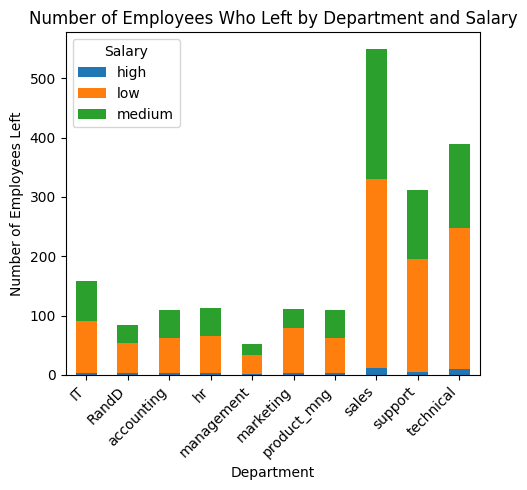

In [ ]:
churn_by_dept_salary = data.groupby(['Department', 'salary'])['left'].sum().unstack()
churn_by_dept_salary.plot(kind='bar', stacked=True, figsize=(5, 5))
plt.title('Number of Employees Who Left by Department and Salary')
plt.xlabel('Department')
plt.ylabel('Number of Employees Left')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Salary')
plt.tight_layout()
plt.show()

**OBSERVATIONS**
1. While most of the dropouts fall under the low - income categories ,there are also a significant amount of middle - income churners.
2. The sales department has seen the a massive amount of dropouts , particularly the low - income categories.
3. Significant amount of dropouts are also seen from Support and Technical Departments.

**SUGGESTED CORRECTIONS**
1. Major attention on the low - income categories . If the employees comprise of lesser skills , consider regular employee upskilling programs . Completion of the programs may be accompanied by incentives such as promotions.
2. Within the low - income categories , top focus must be on sales , support and technical departments.
3. Consider hackathons and competitions with financial benefits for controlling middle - income churn .

#### **CHURN BY NUMBER OF PEOPLE WHO FACED ACCIDENT AT WORK**

In [ ]:
accident_left = (data['Work_accident'] == 1) & (data['left'] == 1)
accident_stayed = (data['Work_accident'] == 1) & (data['left'] == 0)
count_left = data[accident_left].shape[0]
count_stayed = data[accident_stayed].shape[0]
total_accidents = count_left + count_stayed
print("Number of accident survivors who left : " , count_left)
print("Number of accident survivors who stayed : " , count_stayed)
print("Total number of accident survivors :" , total_accidents)

Number of accident survivors who left :  105
Number of accident survivors who stayed :  1745
Total number of accident survivors : 1850


**OBSERVATION** : Only around 5% of those who faced an accident at work left the job , suggesting no strong correlation .

#### **CHURN BY AVERAGE MONTHLY HOURS AND PROMOTION STATUS**

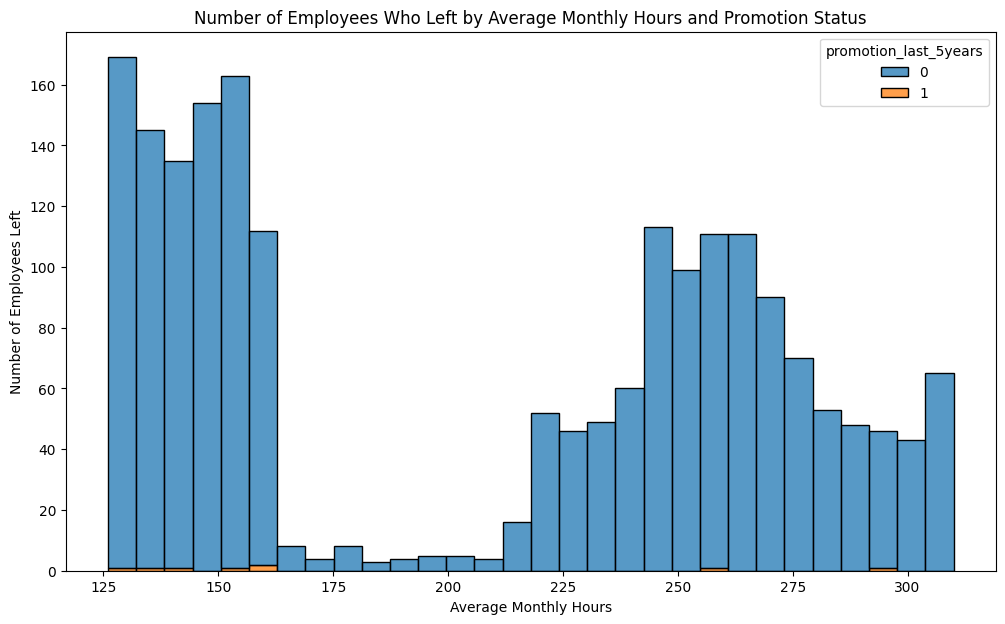

In [ ]:
plt.figure(figsize=(12, 7))
sns.histplot(data=data[data['left'] == 1], x='average_montly_hours', hue='promotion_last_5years', multiple='stack', bins=30)
plt.title('Number of Employees Who Left by Average Monthly Hours and Promotion Status')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Number of Employees Left')
plt.show()

**OBSERVATIONS**:
1. Both overworked employees as well as underworked employees tend to leave
2. Promotion is a very important factor . Promoted people have much less chance of quitting .

#### **DEPARTMENT-WISE PROMOTIONS GROUPED BY SALARY TYPE**


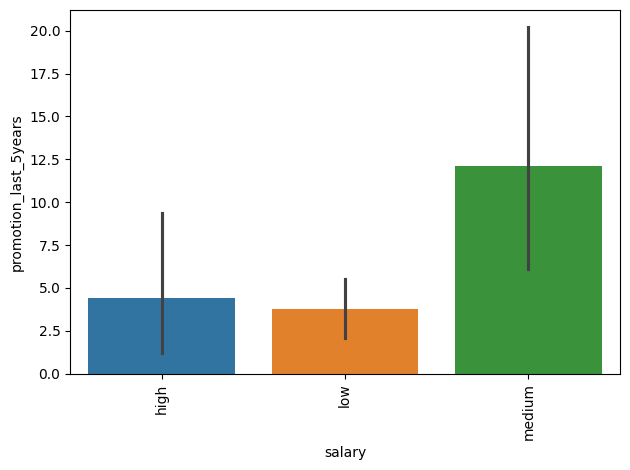

In [ ]:
#Department-Salary Vs Number of Promotions
department_salary_promotions = data.groupby(['Department' , 'salary']).agg({'promotion_last_5years' : 'sum'}).reset_index()
figure1 = sns.barplot(data = department_salary_promotions , x = 'salary' , y = 'promotion_last_5years' , hue = 'salary')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

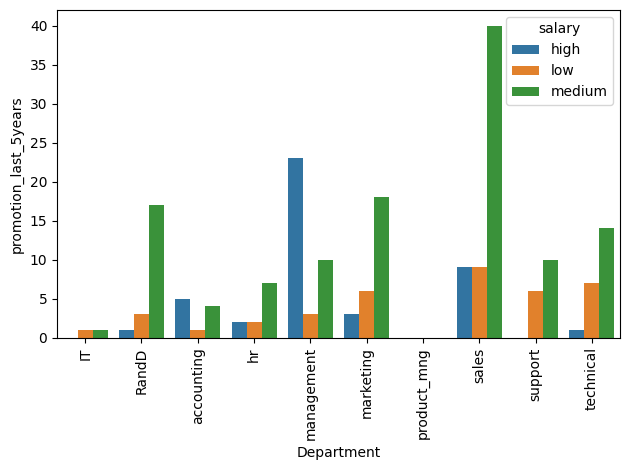

In [ ]:
#Department vs Promotions , grouped by Salary
figure2 = sns.barplot(data = department_salary_promotions , x = 'Department' , y = 'promotion_last_5years' , hue = 'salary')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**OBSERVATIONS**
1. While most promotions happened in sales , least happened in Product Management.
2. Low number of promotions in low - income categories suggest the reasons for the most number of dropouts in low - income categories. Hence , this again emphaises a stronger need of incentivization to the low - income category .

#### **SATISFACTION-LEVEL PLOTS**

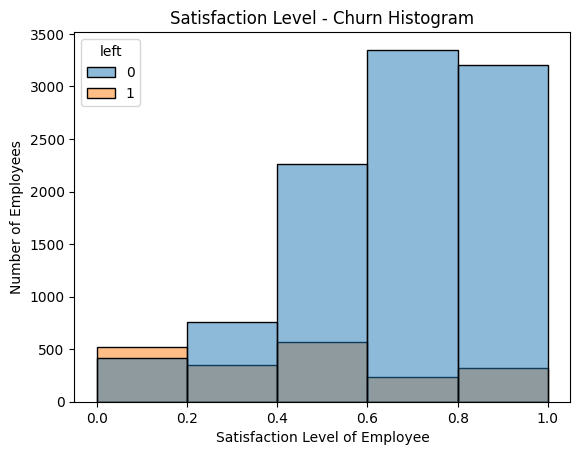

In [ ]:
#Plotting a histogram of satisfaction - levels
figure = sns.histplot(data = data , x = 'satisfaction_level' , bins = [0 , 0.2 , 0.4 , 0.6 , 0.8 , 1.0] , hue = 'left' )
plt.xlabel('Satisfaction Level of Employee')
plt.ylabel('Number of Employees')
plt.title('Satisfaction Level - Churn Histogram')
plt.show()

**OBSERVATIONS** :
1. **Employees with a statisfaction level of 0 - 0.2 are overwhelmingly leavers**.
2. Majority of the employees have a satisfaction level between 0.6 - 0.8 , suggesting that the company is doing great in terms of employee convenience !

**SUGGESTED CORRECTION**
1. Setting up a grievance addressal system for those employees who gave a low satisfaction rating may lead to  a potential improvement in retention.

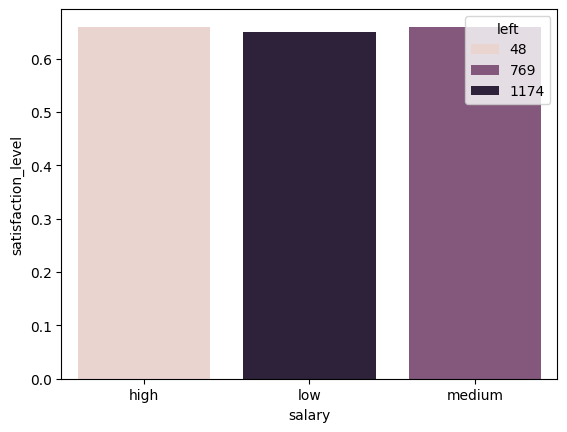

In [ ]:
#Plotting a plot between salary level and average satisfaction level
salary_satisfaction_grouped = data.groupby('salary').agg({'satisfaction_level' : 'median' , 'left' : 'sum'})
figure = sns.barplot(data = salary_satisfaction_grouped , x = 'salary' , y = 'satisfaction_level' , hue = 'left' )

**OBSERVATION** : Salaries and Median satisfaction Levels have no strong correlation

#### **EVALUATING THE WORKLOAD IMBALANCE**

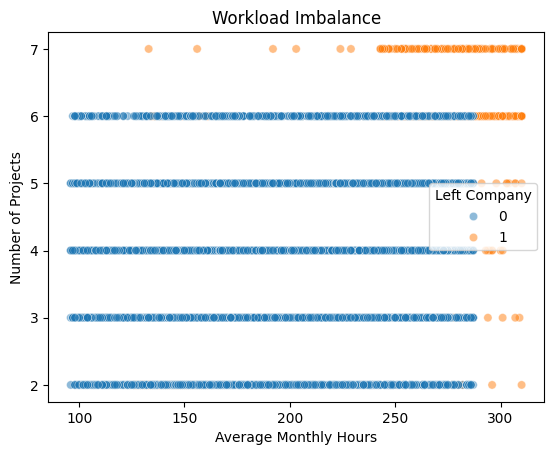

In [ ]:
#Graphing the workload imbalance
figure = sns.scatterplot(data=data, x='average_montly_hours', y='number_project', hue='left' , alpha = 0.5)
plt.title('Workload Imbalance')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Number of Projects')
plt.legend(title='Left Company')
plt.show()

**OBSERVATION** : The graph depicts an important consideration :-
                  **There is a depiction of burnout across the projects spectrum **. Companies must focus on this issue.

#### **EVALUATING PERFORMANCE REVIEW VS DROPOUTS**

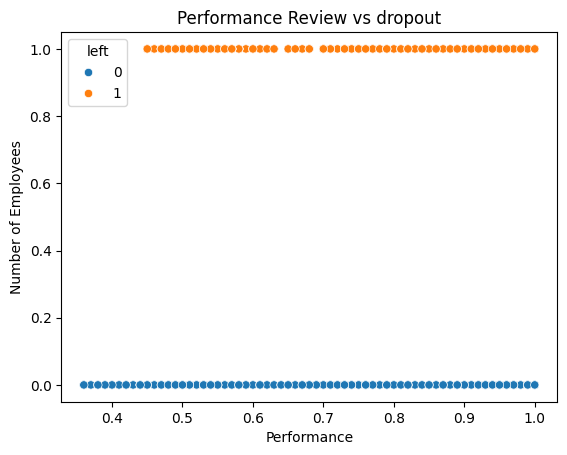

In [ ]:
#Plotting a histogram of satisfaction - levels
figure = sns.scatterplot(data = data , x = 'last_evaluation' , y = 'left' , hue = 'left' )
plt.xlabel('Performance')
plt.ylabel('Number of Employees')
plt.title('Performance Review vs dropout')
plt.show()

**OBSERVATION** : Dropout is independent of the last performance review

# **TRAINING MODELS**
This part takes the cleaned dataset and trains the model

## **SPLITTING THE DATA**

In [ ]:
#Splitting the data into train and test sets
x = data.drop(['left' , 'Department' , 'salary'] , axis = 1)
y = data['left']
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , stratify = y , random_state = 42)
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()
scaler = StandardScaler()
columns_to_scale = ['number_project', 'average_montly_hours', 'time_spend_company' , 'satisfaction_level' , 'last_evaluation']
x_train_scaled[columns_to_scale] = scaler.fit_transform(x_train[columns_to_scale])
x_test_scaled[columns_to_scale] = scaler.transform(x_test[columns_to_scale])

## **TRAINING A LOGISTIC REGRESSION MODEL**

In [ ]:
# #Finding the optimal parameters
# log_clf = LogisticRegression(max_iter = 1000 , solver = 'liblinear')
# param_grid = {'C': [0.01, 0.1, 1, 10, 100] , 'penalty': ['l1', 'l2']}
# best_params = GridSearchCV (log_clf , param_grid=param_grid , scoring = ['precision' , 'recall' , 'f1' , 'accuracy'] , refit = 'f1')
# best_params.fit(x_train_scaled , y_train)
# best_params.best_params_

In [ ]:
#Creating the final logistic regression model
log_clf = LogisticRegression(max_iter = 5000 , solver = 'liblinear' , C = 1 , penalty = 'l1' , class_weight = 'balanced')
log_clf.fit(x_train_scaled , y_train)
y_pred = log_clf.predict(x_test_scaled)
print("Precision : " , precision_score(y_test , y_pred))
print("Recall : " , recall_score(y_test , y_pred))
print("Accuracy : " , accuracy_score(y_test , y_pred))
print("F1 : " , f1_score(y_test , y_pred))

Precision :  0.4298469387755102
Recall :  0.8467336683417085
Accuracy :  0.7882451021258858
F1 :  0.5702199661590525


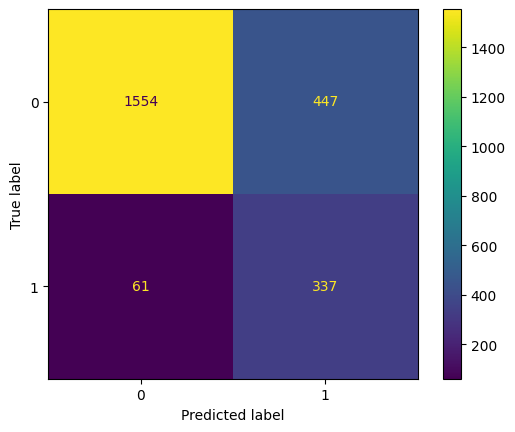

In [ ]:
#Creating a confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## **TRAINING A DECISION TREE REGRESSION MODEL**

In [ ]:
# #Finding the optimal parameters
# dec_clf = DecisionTreeClassifier()
# param_grid = {'max_depth': [None, 5, 10, 15, 20],
#     'min_samples_split': [2, 10, 20],
#     'min_samples_leaf': [1, 5, 10],
#     'max_features': [None, 'sqrt']}
# best_params = GridSearchCV (dec_clf , param_grid=param_grid , scoring = ['precision' , 'recall' , 'f1' , 'accuracy'] , refit = 'f1')
# best_params.fit(x_train , y_train)
# best_params.best_params_

In [ ]:
#Creating the final decision tree classifier model
dec_clf = DecisionTreeClassifier(max_depth = 10 , max_features = None , min_samples_leaf = 1 , min_samples_split = 20 )
dec_clf.fit(x_train , y_train)
y_pred = dec_clf.predict(x_test)
print("Precision : " , precision_score(y_test , y_pred))
print("Recall : " , recall_score(y_test , y_pred))
print("Accuracy : " , accuracy_score(y_test , y_pred))
print("F1 : " , f1_score(y_test , y_pred))

Precision :  0.9813333333333333
Recall :  0.9246231155778895
Accuracy :  0.9845769070446019
F1 :  0.9521345407503234


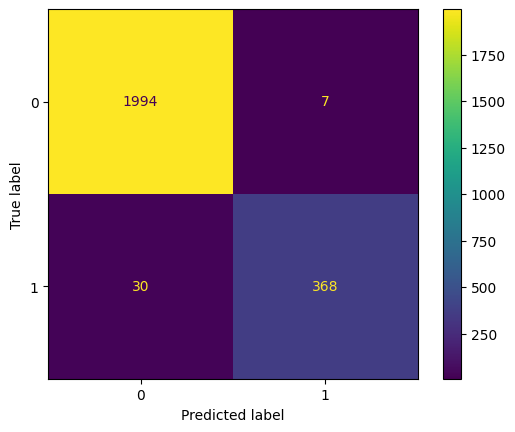

In [ ]:
#Creating a confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## **TRAINING A RANDOM FOREST CLASSIFIER**

In [ ]:
# #Finding the optimal parameters
# ran_clf = RandomForestClassifier()
# param_grid = {'n_estimators': [200, 300],
#     'max_depth': [None, 10, 20],
#     'min_samples_leaf': [1, 5, 10],
#     'min_samples_split': [2, 10],
#     'max_features': ['sqrt'],
#     'class_weight': [None, 'balanced']}
# best_params = GridSearchCV (ran_clf , param_grid=param_grid , scoring = ['precision' , 'recall' , 'f1' , 'accuracy'] , refit = 'f1')
# best_params.fit(x_train , y_train)
# best_params.best_params_

In [ ]:
#Creating the final random forest classifier model
ran_clf = RandomForestClassifier(class_weight = None , max_depth = 20 , min_samples_leaf = 1 , min_samples_split = 2 , n_estimators = 300 )
ran_clf.fit(x_train , y_train)
y_pred = ran_clf.predict(x_test)
print("Precision : " , precision_score(y_test , y_pred))
print("Recall : " , recall_score(y_test , y_pred))
print("Accuracy : " , accuracy_score(y_test , y_pred))
print("F1 : " , f1_score(y_test , y_pred))

Precision :  0.989247311827957
Recall :  0.9246231155778895
Accuracy :  0.9858274280950396
F1 :  0.9558441558441558


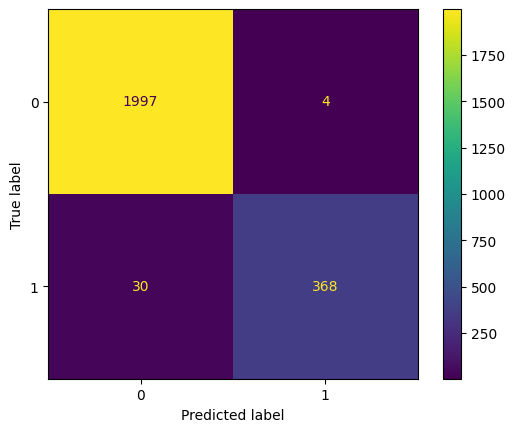

In [ ]:
#Creating a confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## **TRAINING A GRADIENT BOOSTING CLASSIFIER**

In [ ]:
# #Finding the optimal parameters
# XGB_clf = XGBClassifier()
# param_grid = {'n_estimators': [300, 500],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 4, 5],
#     'min_child_weight': [1, 5]}
# best_params = GridSearchCV (XGB_clf , param_grid=param_grid , scoring = ['precision' , 'recall' , 'f1' , 'accuracy'] , refit = 'f1')
# best_params.fit(x_train , y_train)
# best_params.best_params_

In [ ]:
#Creating the final express gradient boosting classifier model
XGB_clf = XGBClassifier(learning_rate = 0.05 , max_depth = 5 , min_child_weight = 1 , n_estimators = 300 )
XGB_clf.fit(x_train , y_train)
y_pred = XGB_clf.predict(x_test)
print("Precision : " , precision_score(y_test , y_pred))
print("Recall : " , recall_score(y_test , y_pred))
print("Accuracy : " , accuracy_score(y_test , y_pred))
print("F1 : " , f1_score(y_test , y_pred))

Precision :  0.9636363636363636
Recall :  0.9321608040201005
Accuracy :  0.9829095456440183
F1 :  0.9476372924648787


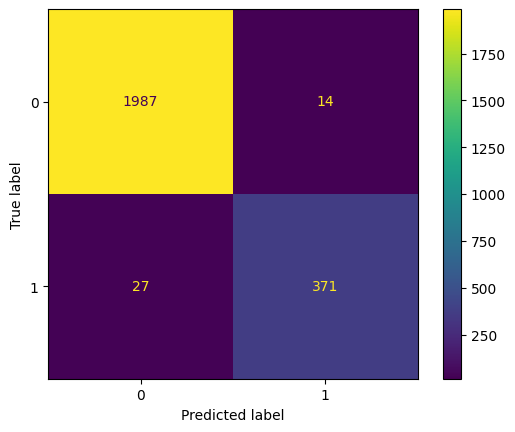

In [ ]:
#Creating a confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# **STORING AND EXPERIMENTING THE RANDOM FOREST CLASSIFIER FOR FUTURE USE**
Since the random forest classifier turns out to be the best model , this will be stored for future use .

In [ ]:
#Storing the model
joblib.dump(ran_clf , 'Best_ESSurvey_Model.joblib')

['Best_ESSurvey_Model.joblib']

In [ ]:
#Fetching the model and displaying feature importances
best_model = joblib.load('Best_ESSurvey_Model.joblib')

importances = best_model.feature_importances_
feature_names = x_train.columns.tolist()
importance_df = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values('Importance', ascending=False)
print(importance_df.head())




                Feature  Importance
0    satisfaction_level    0.314579
2        number_project    0.181478
4    time_spend_company    0.169077
3  average_montly_hours    0.162982
1       last_evaluation    0.127370


# **FINAL OBSERVATIONS AND SUGGESTIONS**
1. The companies must constantly evaluate the satisfaction levels of employees , typical those who have given a rating in between 0 - 0.2 .
2. Both overworked and underworked employees tend to leave (as depicted by the graphs) . Hence , both lack of engagement as well as burnouts contribute to the same pitfall . The company must consider dividing workloads to avoid this situation .
3. Lack of adequate promotions in the past 5 years has led to severe dropouts , especially in the low and medium salary categories . Incentives , upskilling programs as well as hackathons can boost employee retention .
4. **IMPORTANT** :- Feature importances do not always tell the full story . Hence , it is always advised to conduct exploratory data analysis for additional insights. For example , last_evaluation might be considered a relatively important feature here , but the plot shows **NO CORRELATION**. Hence , a double - check is the surest way further .

# **CONCLUSION**
The company now has a trustable model and can take corrective actions using the model's reasoning and results ! However , constant , continual updates as time progresses and as per leadership requests will be considered. Since this project to open to public , your suggestions are highly welcome too !